In [163]:
import pandas as pd
import numpy as np

In [164]:
df=pd.read_csv("breast-cancer.csv")

In [165]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [167]:
df.describe(),df.shape


(                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
 count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
 mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
 std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
 min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
 25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
 50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
 75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
 max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   
 
        smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
 count       569.000000        569.000000      569.000000           569.000000   
 mean          0.096360          0.104341        0.088799             0.048919   
 std           0.014064         

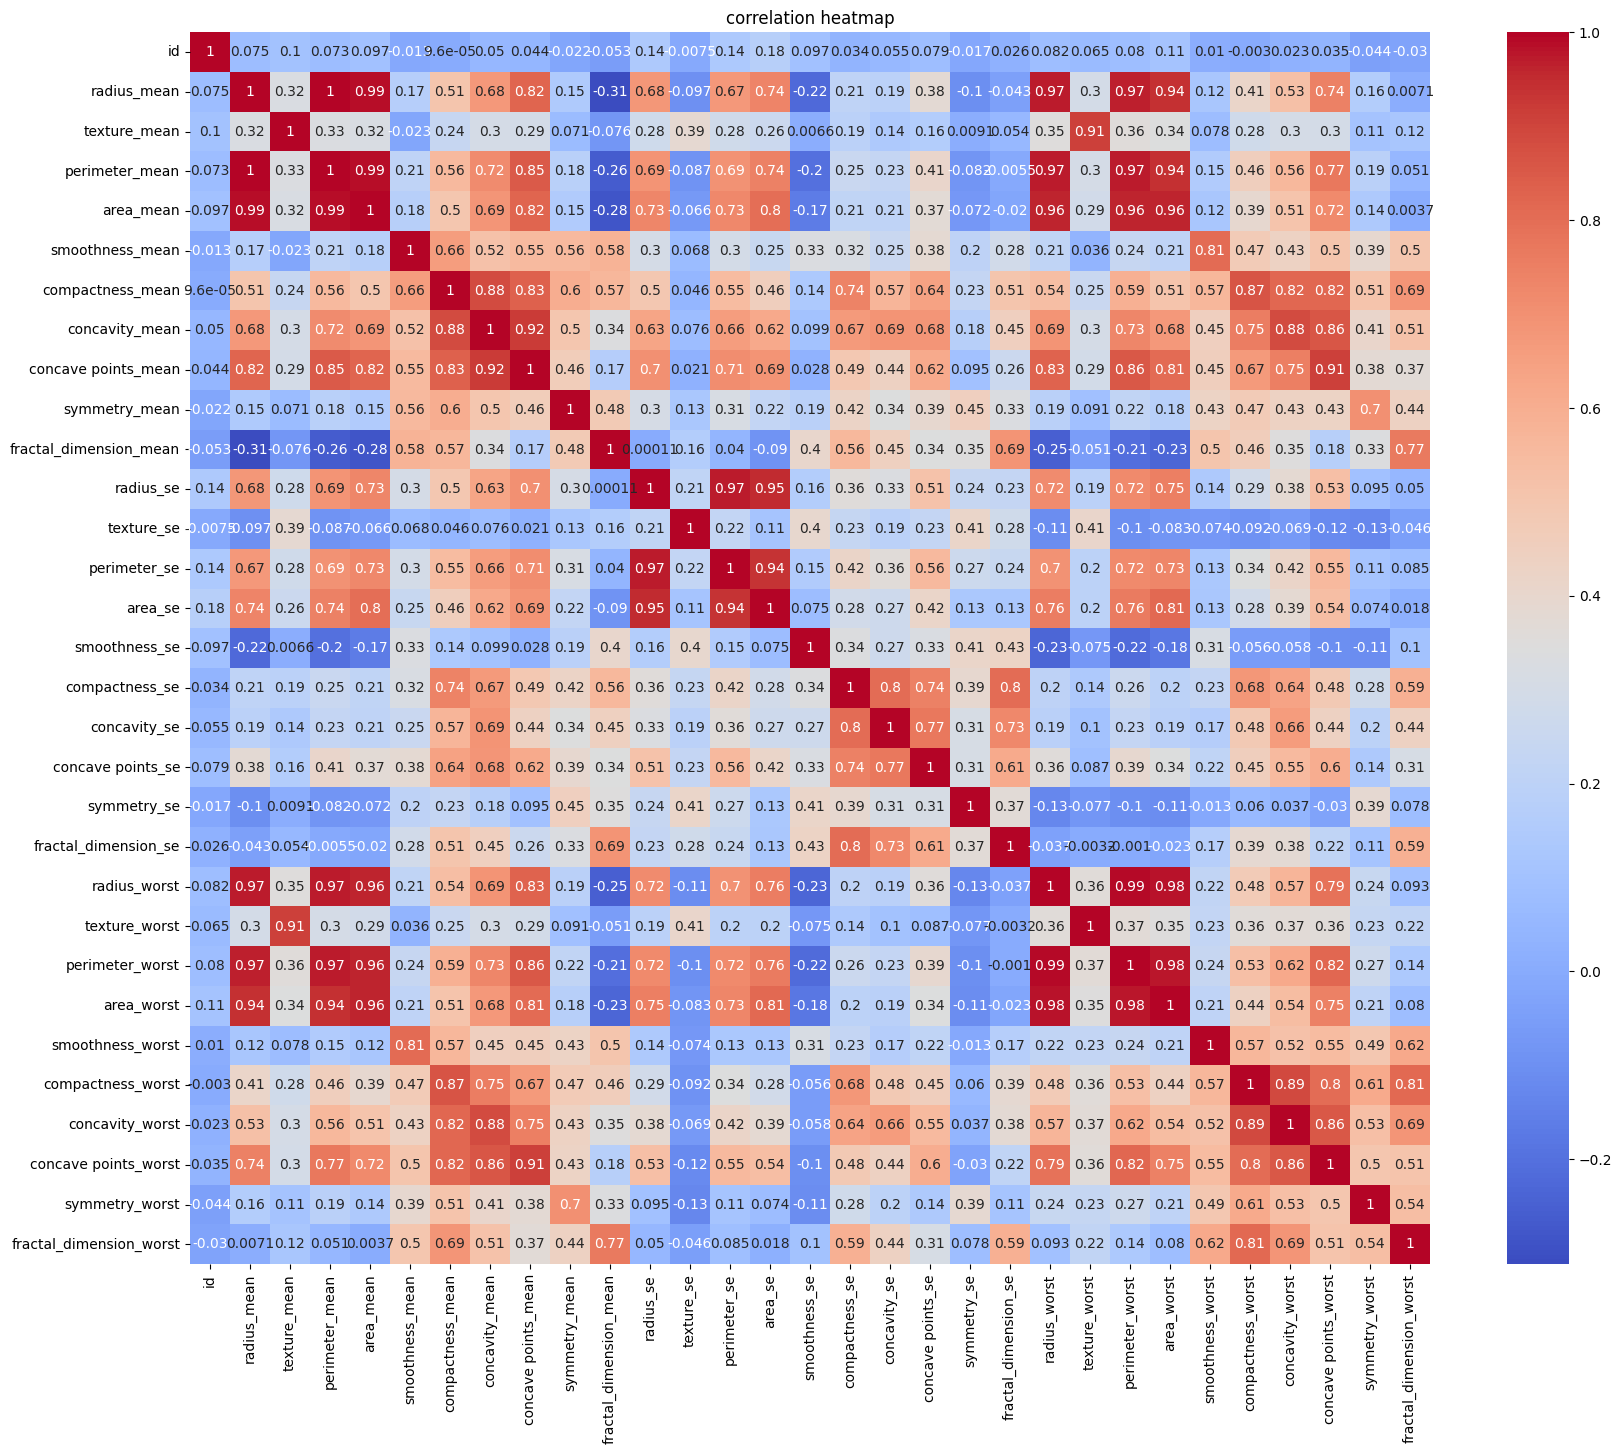

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt
corr=df.corr
plt.figure(figsize=(20,16))
sns.heatmap(corr(numeric_only=True),cmap='coolwarm',annot=True)
plt.title("correlation heatmap")
plt.show()

In [169]:
df['diagnosis']=df['diagnosis'].map({'B': 0,'M':1})

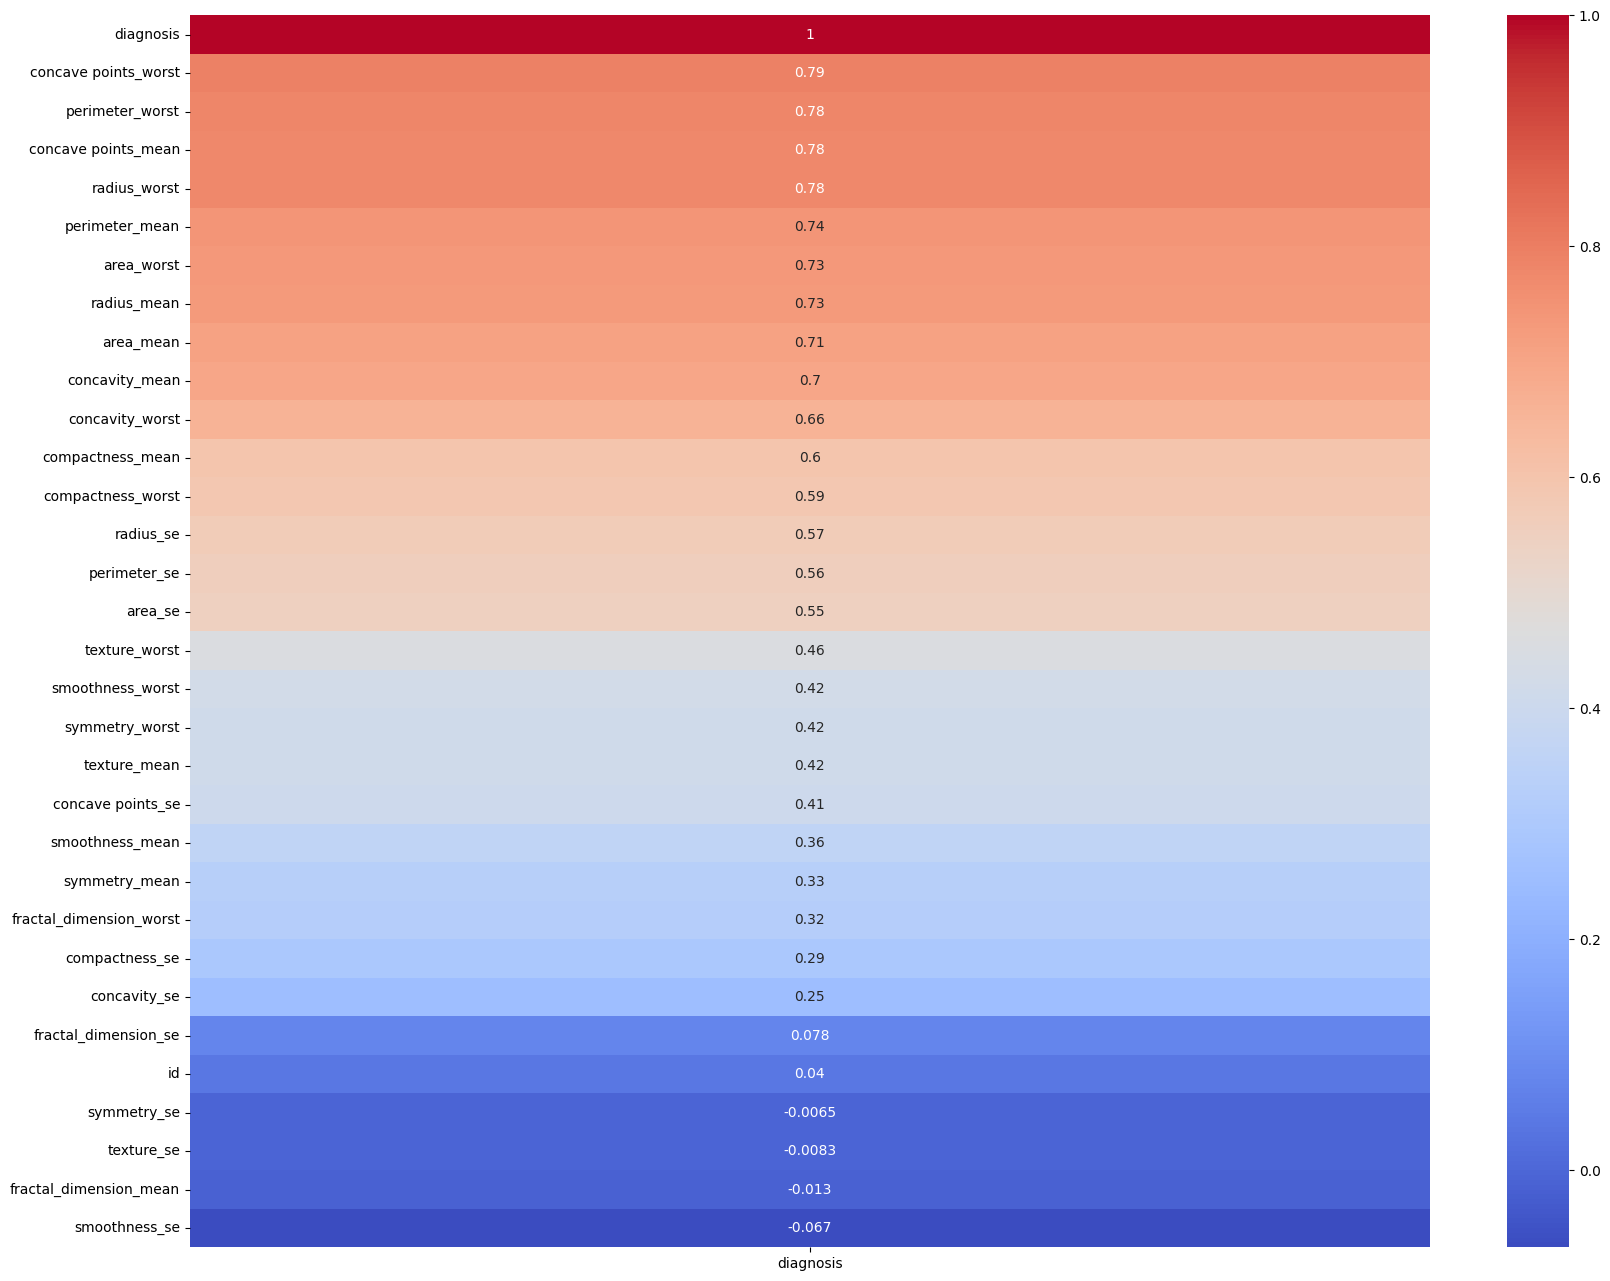

In [170]:
corr=df.corr()
plt.figure(figsize=(20,16))
sns.heatmap(corr[['diagnosis']].sort_values(by='diagnosis',ascending=False),annot=True,cmap='coolwarm')
plt.show()

In [171]:
df.isnull().sum().sort_values(ascending=False)

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [172]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

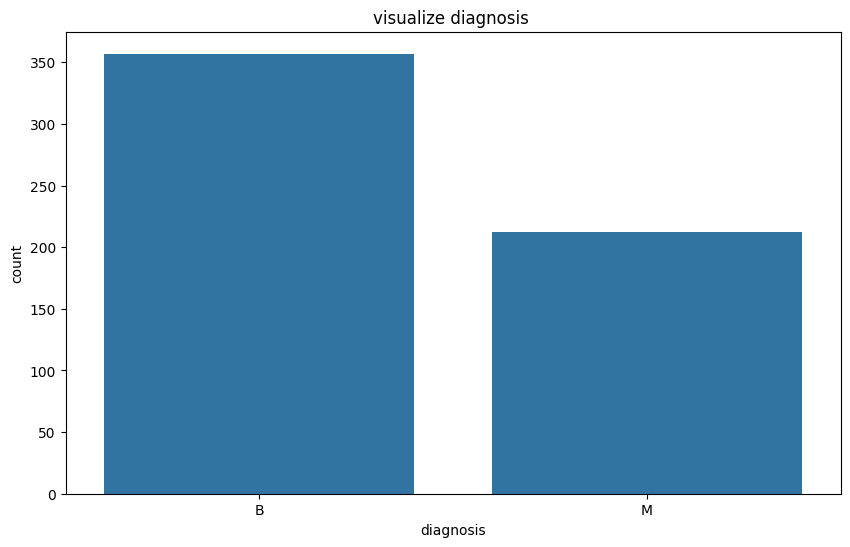

In [173]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['diagnosis'])
plt.title("visualize diagnosis ")

plt.xticks([0,1], ["B", "M"])
plt.show()


In [174]:
X=df.drop(columns=['diagnosis','id','symmetry_se','texture_se','fractal_dimension_worst','smoothness_se'])
y=df['diagnosis']

In [175]:
from sklearn.preprocessing import StandardScaler
scale= StandardScaler()
x_scaled=scale.fit_transform(X)


In [176]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [177]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
models={
    'SVM':SVC(),
    'knn':KNeighborsClassifier(),
    'logstic regression':LogisticRegression(),
    'ID3':DecisionTreeClassifier(),
    'random forest':RandomForestClassifier()

}

In [178]:
from sklearn.model_selection import cross_val_score
scores = []
for model_name , model in models.items() :
    test = cross_val_score(model , x_scaled , y , cv = 5 , scoring='accuracy')
    scores.append({'model' : model_name , 'Score' : test.mean()})
s = pd.DataFrame(scores)
s  

,model,Score
0,SVM,0.971883
1,knn,0.968359
2,logstic regression,0.980686
3,ID3,0.927899
4,random forest,0.963127


In [179]:

from sklearn.model_selection import GridSearchCV

mod = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}
grid_search=GridSearchCV(
    estimator=mod,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)
grid_search.fit(X_train,y_train)
print("Best parameters:", grid_search.best_params_)
print("Best score:",grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}
Best score: 0.9582417582417584


In [180]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

md=RandomForestClassifier(max_depth=None,min_samples_split=2,n_estimators=500)
md.fit(X_train, y_train)
# Predict on test set
y_pred = md.predict(X_test)
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
# ROC AUC using cross-validation
roc = cross_val_score(md, x_scaled, y, cv=5, scoring="roc_auc").mean()
print("ROC AUC (Cross-Validation):", roc)


Accuracy: 0.9736842105263158
ROC AUC (Cross-Validation): 0.991362624498065


              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



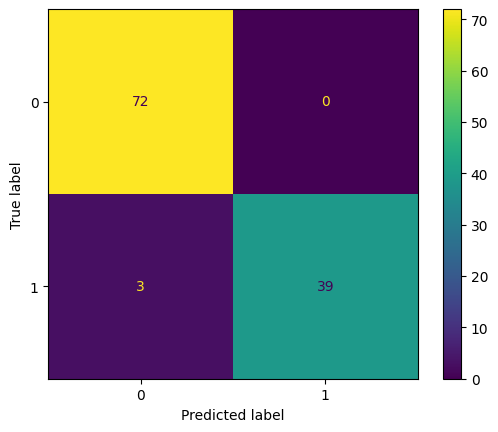

In [181]:

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
print(classification_report(y_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

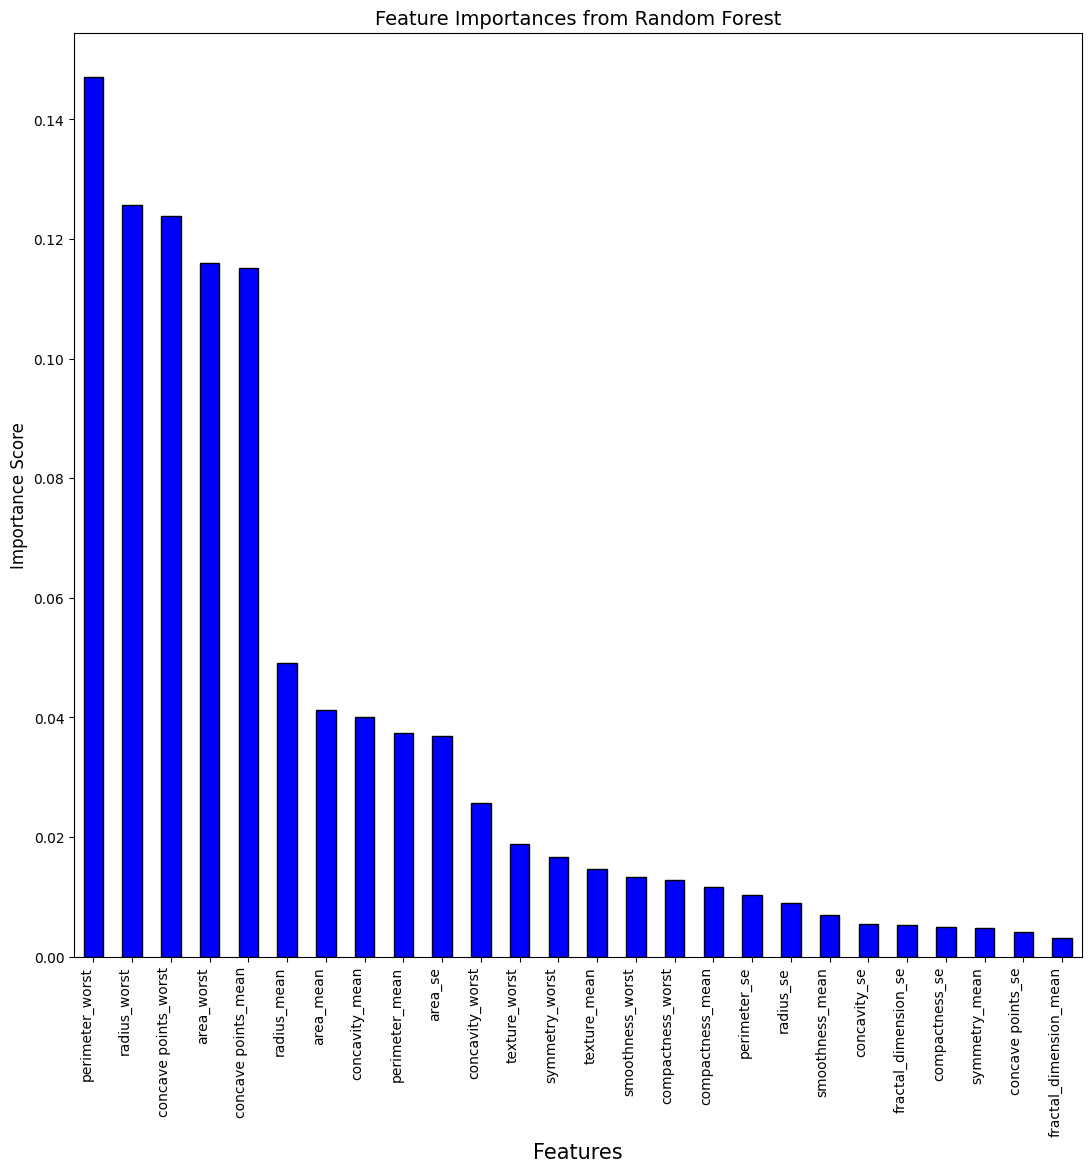

In [187]:
feature_importances = pd.Series(md.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(13,12))
feature_importances.plot(kind='bar', color='blue', edgecolor='black')
plt.title("Feature Importances from Random Forest", fontsize=14)
plt.xlabel("Features", fontsize=15)
plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.show()
